In [1]:
# ── RASTREABILIDADE EXPERIMENTAL ─────────────────────────────────────────────
# Preencha antes de cada treino. Salvo automaticamente no CSV de resultados.

EXPERIMENTO = {
    "id"       : "exp_002",
    "hipotese" : (
        "A saída auxiliar supera a principal em ~6.5pp, indicando underfitting "
        "na cabeça principal. Aumentar Dropout de 0.4 → 0.55 deve forçar maior "
        "regularização antes do classificador final e reduzir essa diferença."
    ),
    "mudancas" : [
        # Acumulado: exp_001 mantido
        "[exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)",
        "[exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)",
        # Novo: exp_002
        "[exp_002] main_dropout: 0.4 → 0.55",
    ],
    "resultado_top1" : None,
    "resultado_top5" : None,
    "epocas"         : None,
}

import datetime
print(f"[{datetime.datetime.now():%Y-%m-%d %H:%M}] Experimento: {EXPERIMENTO['id']}")
print(f"Hipótese: {EXPERIMENTO['hipotese']}")
print("Mudanças acumuladas:")
for m in EXPERIMENTO["mudancas"]:
    print(f"  • {m}")


[2026-04-30 16:36] Experimento: exp_002
Hipótese: A saída auxiliar supera a principal em ~6.5pp, indicando underfitting na cabeça principal. Aumentar Dropout de 0.4 → 0.55 deve forçar maior regularização antes do classificador final e reduzir essa diferença.
Mudanças acumuladas:
  • [exp_001] inception_5a: (256,160,320,32,128,128) → (192,128,256,32,96,96)
  • [exp_001] inception_5b: (384,192,384,48,128,128) → (256,160,320,32,96,96)
  • [exp_002] main_dropout: 0.4 → 0.55


## Histórico de Experimentos

| ID | Hipótese | Mudanças | Top-1 val | Top-5 val | Δ Top-1 |
|---|---|---|---|---|---|
| baseline | — | Modelo original | 39.88% | — | — |
| exp_001 | Filtros 5a/5b grandes demais para mapa 8×8 | inception_5a: 832→640 ch · inception_5b: 1024→768 ch | 40.08% | — | +0.20pp |
| exp_002 | Auxiliar supera principal em 6.5pp → underfitting na cabeça | main_dropout: 0.4→0.55 | *(pendente)* | *(pendente)* | — |

> **Regra:** cada experimento é incremental — mudanças validadas são mantidas.  
> Reverter apenas se o exp atual piorar em relação ao anterior.


# GoogLeNet (InceptionV1) — Tiny ImageNet

**Dataset:** Tiny ImageNet (Stanford) — 200 classes, 64×64px, 100k imagens de treino + 10k de validação  
**Arquitetura:** GoogLeNet/InceptionV1 adaptado para imagens 64×64  
**Ambiente recomendado:** Kaggle (GPU T4/P100) ou Google Colab (GPU)

---
### Diferenças em relação à versão CIFAR-10
| Aspecto | CIFAR-10 | Tiny ImageNet |
|---|---|---|
| Resolução | 32×32 | 64×64 |
| Classes | 10 | 200 |
| Treino | 50k | 100k |
| Stem | kernel 7×7 (agressivo) | kernel 3×3 (preserva resolução) |
| Módulos Inception | 4 | 7 |
| Saída | softmax(10) | softmax(200) |

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import zipfile
import requests
from PIL import Image
from io import BytesIO
from pathlib import Path

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")
from sklearn.metrics import classification_report, confusion_matrix


2026-04-30 16:36:49.871833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777567010.064294      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777567010.118596      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777567010.540345      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777567010.540396      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777567010.540398      22 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configurações Globais

In [3]:
# ── Hiperparâmetros ──────────────────────────────────────────────────────────
EPOCHS          = 100          # Tiny ImageNet converge bem em ~80-100 épocas
BATCH_SIZE      = 128          # Ajuste para 64 se der OOM na GPU
NUM_CLASSES     = 200          # Tiny ImageNet tem 200 classes
IMG_SIZE        = 64           # Resolução nativa do Tiny ImageNet
INITIAL_LR     = 0.01
LR_DROP_FACTOR = 0.96
LR_DROP_PERIOD = 5
USE_AUGMENTATION = True

# ── Reprodutibilidade ────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

print(f"Configuração: {EPOCHS} épocas | batch {BATCH_SIZE} | {IMG_SIZE}×{IMG_SIZE} | {NUM_CLASSES} classes")

Configuração: 100 épocas | batch 128 | 64×64 | 200 classes


## Download e Extração do Tiny ImageNet

O Tiny ImageNet está hospedado na Stanford. Fazemos o download (~236 MB), extraímos e reorganizamos a pasta de validação (que vem em formato diferente do treino).

In [4]:
TINY_URL  = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
DATA_DIR  = Path('/kaggle/working/tiny-imagenet-200')   # ajuste se necessário
ZIP_PATH  = Path('/kaggle/working/tiny-imagenet-200.zip')

# ── Download ─────────────────────────────────────────────────────────────────
if not ZIP_PATH.exists():
    print('Baixando Tiny ImageNet (~236 MB)...')
    r = requests.get(TINY_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    downloaded = 0
    with open(ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)
            downloaded += len(chunk)
            print(f'\r  {downloaded/1e6:.1f}/{total/1e6:.1f} MB', end='')
    print('\nDownload completo!')
else:
    print('ZIP já existe, pulando download.')

# ── Extração ─────────────────────────────────────────────────────────────────
if not DATA_DIR.exists():
    print('Extraindo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/kaggle/working')
    print('Extração concluída.')
else:
    print('Diretório já existe, pulando extração.')

print(f'Dataset em: {DATA_DIR}')

Baixando Tiny ImageNet (~236 MB)...
  248.1/248.1 MB
Download completo!
Extraindo...
Extração concluída.
Dataset em: /kaggle/working/tiny-imagenet-200


In [5]:
# ── Reorganiza pasta de validação ─────────────────────────────────────────────
# A pasta val do Tiny ImageNet coloca todas as imagens numa pasta flat com um
# arquivo val_annotations.txt indicando a classe de cada imagem.
# Aqui reorganizamos para o formato class/image.JPEG que o Keras espera.

import shutil

val_dir        = DATA_DIR / 'val'
val_img_dir    = val_dir / 'images'
val_annot_file = val_dir / 'val_annotations.txt'
val_organized  = DATA_DIR / 'val_organized'

if not val_organized.exists():
    print('Reorganizando val/ para estrutura class/image...')
    val_organized.mkdir(parents=True)
    with open(val_annot_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            fname, class_id = parts[0], parts[1]
            class_dir = val_organized / class_id
            class_dir.mkdir(exist_ok=True)
            shutil.copy(val_img_dir / fname, class_dir / fname)
    print(f'Validação reorganizada: {len(list(val_organized.iterdir()))} classes')
else:
    print('val_organized já existe.')

TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = val_organized
print(f'Treino: {TRAIN_DIR}')
print(f'Val:    {VAL_DIR}')

Reorganizando val/ para estrutura class/image...
Validação reorganizada: 200 classes
Treino: /kaggle/working/tiny-imagenet-200/train
Val:    /kaggle/working/tiny-imagenet-200/val_organized


## Pipeline de Dados com `image_dataset_from_directory`

Usamos a API do Keras para criar datasets eficientes (sem carregar tudo na RAM).

In [6]:
# ── Carregamento ──────────────────────────────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print(f'Classes encontradas: {len(CLASS_NAMES)}')
print(f'Primeiras 5: {CLASS_NAMES[:5]}')

# Guarda o mapeamento class_id → índice para uso na predição
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

Found 100000 files belonging to 200 classes.


I0000 00:00:1777567095.783578      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 10000 files belonging to 200 classes.
Classes encontradas: 200
Primeiras 5: ['n01443537', 'n01629819', 'n01641577', 'n01644900', 'n01698640']


In [7]:
# ── Normalização e Augmentation ───────────────────────────────────────────────
def normalize(image, label):
    """Normaliza pixel [0,255] → [0,1]."""
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(normalize,   num_parallel_calls=tf.data.AUTOTUNE)

if USE_AUGMENTATION:
    augment = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1),
    ], name='augmentation')

    def augment_fn(image, label):
        return augment(image, training=True), label

    train_ds = train_ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch para sobreposição CPU/GPU
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

print('Pipelines de dados prontos.')

Pipelines de dados prontos.


## Visualização de Amostras do Dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0150816].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0069929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.09244728..1.014759].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.028681457..1.0052165].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0101012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0028319].


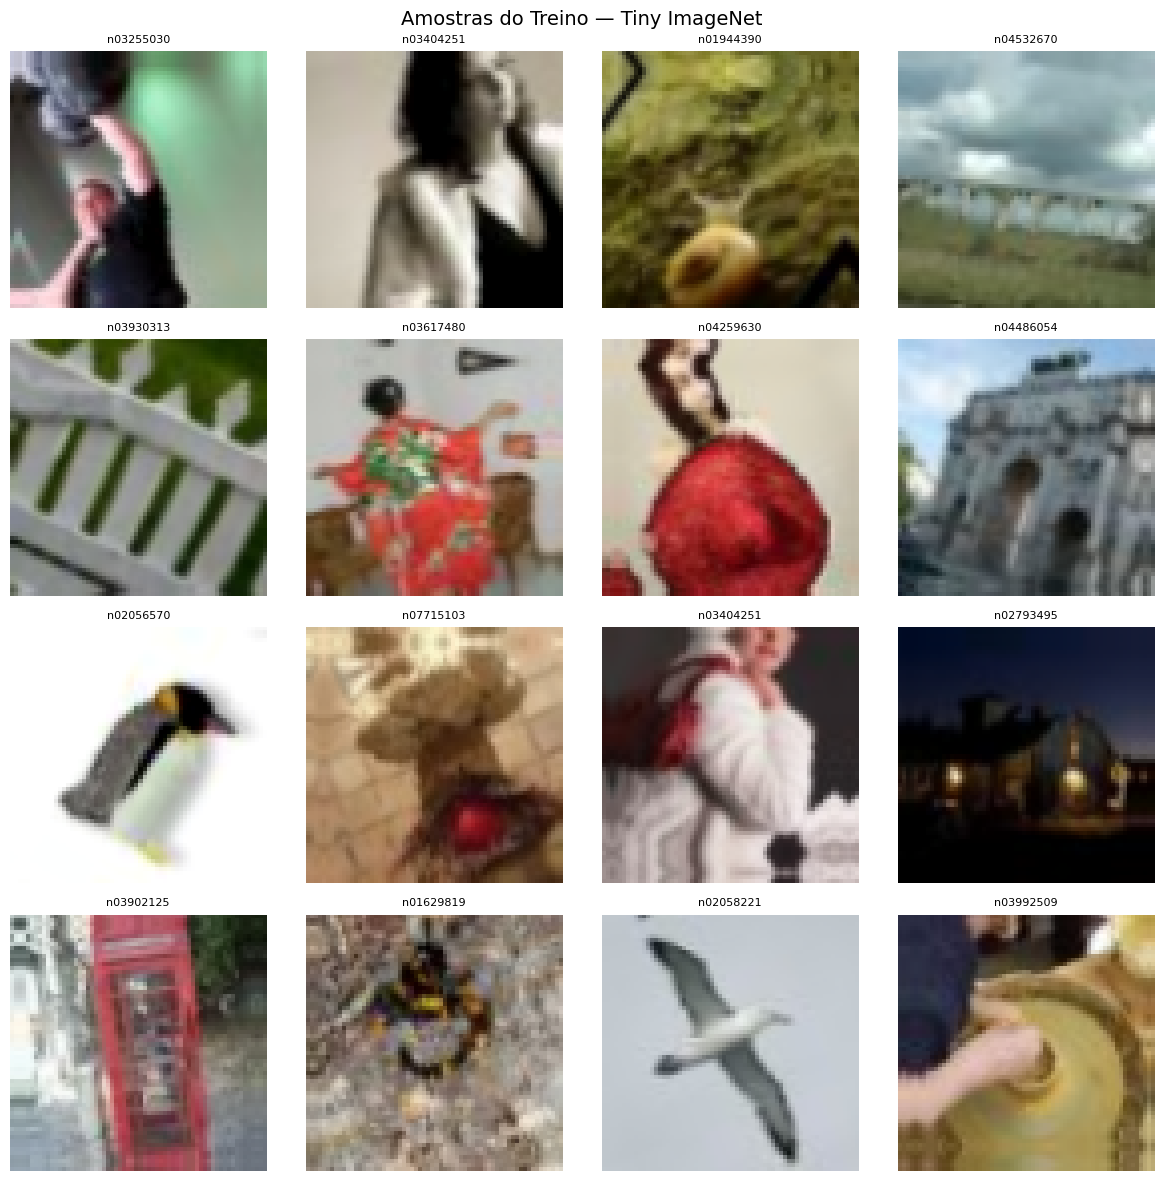

In [8]:
# Exibe 16 imagens de treino com seus rótulos
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy())
        class_idx = np.argmax(labels[i].numpy())
        ax.set_title(CLASS_NAMES[class_idx], fontsize=8)
        ax.axis('off')
plt.suptitle('Amostras do Treino — Tiny ImageNet', fontsize=14)
plt.tight_layout()
plt.show()

## Módulo Inception

O módulo permanece idêntico ao original — 4 ramos paralelos (1×1, 3×3, 5×5, pool+proj) concatenados no eixo de canais.

In [9]:
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5, filters_pool_proj, name=None):
    """Módulo Inception com 4 ramos paralelos (Szegedy et al., 2014)."""
    kw_init = 'glorot_uniform'
    b_init  = tf.keras.initializers.Constant(0.2)

    # Ramo 1 — convolução 1×1
    b1 = tf.keras.layers.Conv2D(
        filters_1x1, (1, 1), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_1x1')(x)

    # Ramo 2 — redução 1×1 → convolução 3×3
    b2 = tf.keras.layers.Conv2D(
        filters_3x3_reduce, (1, 1), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_3x3_reduce')(x)
    b2 = tf.keras.layers.Conv2D(
        filters_3x3, (3, 3), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_3x3')(b2)

    # Ramo 3 — redução 1×1 → convolução 5×5
    b3 = tf.keras.layers.Conv2D(
        filters_5x5_reduce, (1, 1), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_5x5_reduce')(x)
    b3 = tf.keras.layers.Conv2D(
        filters_5x5, (5, 5), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_5x5')(b3)

    # Ramo 4 — MaxPool 3×3 → projeção 1×1
    b4 = tf.keras.layers.MaxPooling2D(
        (3, 3), strides=(1, 1), padding='same',
        name=f'{name}_pool')(x)
    b4 = tf.keras.layers.Conv2D(
        filters_pool_proj, (1, 1), padding='same', activation='relu',
        kernel_initializer=kw_init, bias_initializer=b_init,
        name=f'{name}_pool_proj')(b4)

    return tf.keras.layers.Concatenate(axis=-1, name=name)([b1, b2, b3, b4])

## Construção do Modelo — GoogLeNet adaptado para 64×64

### Decisões de projeto

**Stem:** O GoogLeNet original usa kernel 7×7 stride-2 → MaxPool stride-2 → MaxPool stride-2, o que reduz 224→28px. Aplicar isso a imagens 64×64 colapsaria o mapa para apenas ~4px antes do primeiro módulo Inception, destruindo informação espacial. Solução: substituímos o kernel 7×7 por dois blocos 3×3 consecutivos com stride-1 e mantemos apenas **um** MaxPool stride-2, preservando um mapa de 32×32 antes dos Inceptions.

**Classificador Auxiliar:** Posicionado após o bloco Inception 4a, com peso 0.3 na loss, igual ao paper original.

**Camadas Inception:** 7 módulos (3a, 3b, 4a, 4b, 4c, 4d, 4e) vs. 4 na versão CIFAR-10.

In [10]:
inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_layer')

# ── Stem ─────────────────────────────────────────────────────────────────────
x = tf.keras.layers.Conv2D(
    64, (3, 3), strides=(1, 1), padding='same', activation='relu',
    kernel_initializer='glorot_uniform',
    bias_initializer=tf.keras.initializers.Constant(0.2),
    name='stem_conv1')(inputs)
x = tf.keras.layers.Conv2D(
    64, (3, 3), padding='same', activation='relu',
    kernel_initializer='glorot_uniform',
    bias_initializer=tf.keras.initializers.Constant(0.2),
    name='stem_conv2')(x)
x = tf.keras.layers.Conv2D(
    192, (3, 3), padding='same', activation='relu',
    kernel_initializer='glorot_uniform',
    bias_initializer=tf.keras.initializers.Constant(0.2),
    name='stem_conv3')(x)
x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same', name='stem_pool')(x)

# ── Bloco Inception 3 ────────────────────────────────────────────────────────
x = inception_module(x, 64,  96, 128, 16,  32,  32,  name='inception_3a')
x = inception_module(x, 128, 128, 192, 32,  96,  64,  name='inception_3b')
x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same', name='pool_3')(x)

# ── Bloco Inception 4 ────────────────────────────────────────────────────────
x = inception_module(x, 192, 96,  208, 16, 48, 64,  name='inception_4a')

# Classificador Auxiliar
aux = tf.keras.layers.AveragePooling2D((5, 5), strides=3, padding='same', name='aux_avgpool')(x)
aux = tf.keras.layers.Conv2D(128, (1, 1), padding='same', activation='relu', name='aux_conv')(aux)
aux = tf.keras.layers.Flatten(name='aux_flatten')(aux)
aux = tf.keras.layers.Dense(1024, activation='relu', name='aux_dense1')(aux)
aux = tf.keras.layers.Dropout(0.3, name='aux_dropout')(aux)
aux_out = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='auxiliary_output')(aux)

x = inception_module(x, 160, 112, 224, 24, 64, 64,  name='inception_4b')
x = inception_module(x, 128, 128, 256, 24, 64, 64,  name='inception_4c')
x = inception_module(x, 112, 144, 288, 32, 64, 64,  name='inception_4d')
x = inception_module(x, 256, 160, 320, 32, 128, 128, name='inception_4e')
x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same', name='pool_4')(x)

# ── Bloco Inception 5 — AJUSTADO (exp_001) ───────────────────────────────────
# Hipótese: canais originais (832/1024) são grandes demais para mapa 8×8
# vindo de entrada 64×64. Redução de ~30% alivia overfitting na cabeça principal.
x = inception_module(x, 192, 128, 256, 32,  96,  96,  name='inception_5a')  # saída: 640 ch
x = inception_module(x, 256, 160, 320, 32,  96,  96,  name='inception_5b')  # saída: 768 ch

# ── Cabeça de Classificação ───────────────────────────────────────────────────
x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = tf.keras.layers.Dropout(0.55, name='main_dropout')(x)  # exp_002: 0.4 → 0.55
main_out = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='main_output')(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=[main_out, aux_out],
    name='GoogLeNet_TinyImageNet'
)
model.summary()


Model: "GoogLeNet_TinyImageNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1 (Conv2D) │ (None, 64, 64,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv2 (Conv2D) │ (None, 64, 64,    │     36,928 │ stem_conv1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv3 (Conv2D) │ (None, 64, 64,    │    110,784 │ stem_conv2[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_conv3[0][0]  │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3_r… │ (None, 32, 32,    │     18,528 │ stem_pool[0][0]   │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5_r… │ (None, 32, 32,    │      3,088 │ stem_pool[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool   │ (None, 32, 32,    │          0 │ stem_pool[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_1x1    │ (None, 32, 32,    │     12,352 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_3x3    │ (None, 32, 32,    │    110,720 │ inception_3a_3x3… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_5x5    │ (None, 32, 32,    │     12,832 │ inception_3a_5x5… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a_pool_… │ (None, 32, 32,    │      6,176 │ inception_3a_poo… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3a        │ (None, 32, 32,    │          0 │ inception_3a_1x1… │
│ (Concatenate)       │ 256)              │            │ inception_3a_3x3… │
│                     │                   │            │ inception_3a_5x5… │
│                     │                   │            │ inception_3a_poo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_3x3_r… │ (None, 32, 32,    │     32,896 │ inception_3a[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_5x5_r… │ (None, 32, 32,    │      8,224 │ inception_3a[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_3b_pool   │ (None, 32, 32,    │          0 │ inception_3a[0][… │
│ (MaxPooling2D)      │ 256)              │            │                 

 Total params: 10,287,152 (39.24 MB)

 Trainable params: 10,287,152 (39.24 MB)

 Non-trainable params: 0 (0.00 B)

## Compilação e Callbacks

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=INITIAL_LR, momentum=0.9, nesterov=True
    ),
    loss={
        'main_output': 'categorical_crossentropy',
        'auxiliary_output': 'categorical_crossentropy'
    },
    loss_weights={'main_output': 1.0, 'auxiliary_output': 0.3},
    metrics={
        'main_output': ['accuracy'],
        'auxiliary_output': ['accuracy']
    }
)
print("Modelo compilado com sucesso!")

Modelo compilado com sucesso!


In [12]:
# ── Learning Rate Scheduler ───────────────────────────────────────────────────
def lr_scheduler(epoch):
    return INITIAL_LR * (LR_DROP_FACTOR ** int((epoch + 1) / LR_DROP_PERIOD))

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_main_output_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='max'          # CORREÇÃO
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'googlenet_tinyimagenet_best.keras',
    monitor='val_main_output_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max'          # CORREÇÃO
)

csv_logger = tf.keras.callbacks.CSVLogger('training_log.csv')

## Treinamento

> **Nota sobre o dataset com 2 saídas:** Como o modelo tem `[main_output, auxiliary_output]`, precisamos passar os labels duas vezes em cada batch. Fazemos isso com um dataset wrapper que duplica os labels.

In [13]:
# Duplica os labels para as 2 saídas do modelo
def duplicate_labels(image, label):
    return image, (label, label)

train_ds_dual = train_ds.map(duplicate_labels)
val_ds_dual   = val_ds.map(duplicate_labels)

print(f'Iniciando treinamento — {EPOCHS} épocas máx.')
history = model.fit(
    train_ds_dual,
    validation_data=val_ds_dual,
    epochs=EPOCHS,
    callbacks=[lr_callback, early_stop, checkpoint, csv_logger],
    verbose=1
)

Iniciando treinamento — 100 épocas máx.

Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/100


I0000 00:00:1777567109.252882      71 service.cc:152] XLA service 0x7d5190002330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777567109.252925      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777567111.092448      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777567144.890525      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - auxiliary_output_accuracy: 0.0055 - auxiliary_output_loss: 5.3064 - loss: 6.9202 - main_output_accuracy: 0.0049 - main_output_loss: 5.3283
Epoch 1: val_main_output_accuracy improved from -inf to 0.00500, saving model to googlenet_tinyimagenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 289s 314ms/step - auxiliary_output_accuracy: 0.0055 - auxiliary_output_loss: 5.3064 - loss: 6.9202 - main_output_accuracy: 0.0049 - main_output_loss: 5.3282 - val_auxiliary_output_accuracy: 0.0049 - val_auxiliary_output_loss: 5.2963 - val_loss: 6.8872 - val_main_output_accuracy: 0.0050 - val_main_output_loss: 5.2983 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - auxiliary_output_accuracy: 0.0080 - auxiliary_output_loss: 5.2576 - loss: 6.8756 - main_output_accuracy: 0.0046 - main_output_loss: 5.2983
Epoch 2: val_main_output_accuracy improved from 0.00500 to 0.01080, sav

## Avaliação e Visualização de Resultados

In [14]:
# Carrega o mapeamento class_id → nome legível (words.txt do dataset)
words_file = DATA_DIR / 'words.txt'
id_to_name = {}
if words_file.exists():
    with open(words_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                id_to_name[parts[0]] = parts[1].split(',')[0]  # pega o primeiro sinônimo

# Cria lista final: índice → nome legível
idx_to_readable = {}
for i, class_id in enumerate(CLASS_NAMES):
    idx_to_readable[i] = id_to_name.get(class_id, class_id)

print('Amostra de mapeamento:')
for i in range(5):
    print(f'  [{i}] {CLASS_NAMES[i]} → "{idx_to_readable[i]}')

Amostra de mapeamento:
  [0] n01443537 → "goldfish
  [1] n01629819 → "European fire salamander
  [2] n01641577 → "bullfrog
  [3] n01644900 → "tailed frog
  [4] n01698640 → "American alligator



Acurácia Final — Saída Principal (val): 39.29%
Acurácia Final — Saída Auxiliar  (val): 46.58%


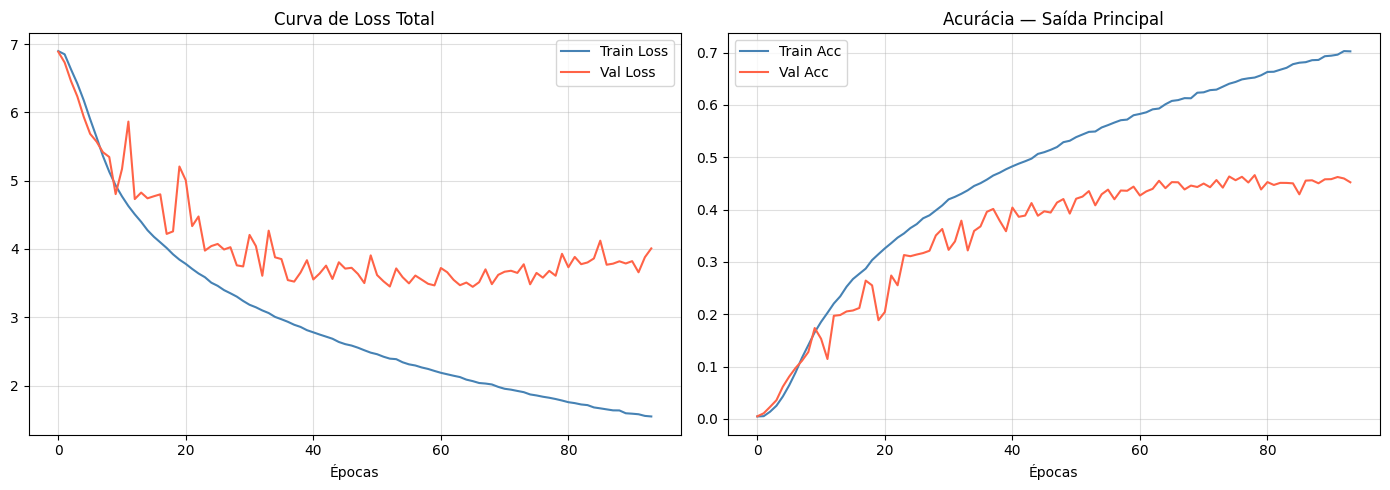

Gráfico salvo em training_curves.png


In [15]:
# Carrega o melhor checkpoint salvo
best_model = tf.keras.models.load_model('googlenet_tinyimagenet_best.keras')

# Avalia na validação
results = best_model.evaluate(val_ds_dual, verbose=0)
print(f'\nAcurácia Final — Saída Principal (val): {results[3]*100:.2f}%')
print(f'Acurácia Final — Saída Auxiliar  (val): {results[4]*100:.2f}%')

# ── Curvas de Loss e Acurácia ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].set_title('Curva de Loss Total')
axes[0].set_xlabel('Épocas')
axes[0].legend()
axes[0].grid(alpha=0.4)

axes[1].plot(history.history['main_output_accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_main_output_accuracy'], label='Val Acc',   color='tomato')
axes[1].set_title('Acurácia — Saída Principal')
axes[1].set_xlabel('Épocas')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Gráfico salvo em training_curves.png')

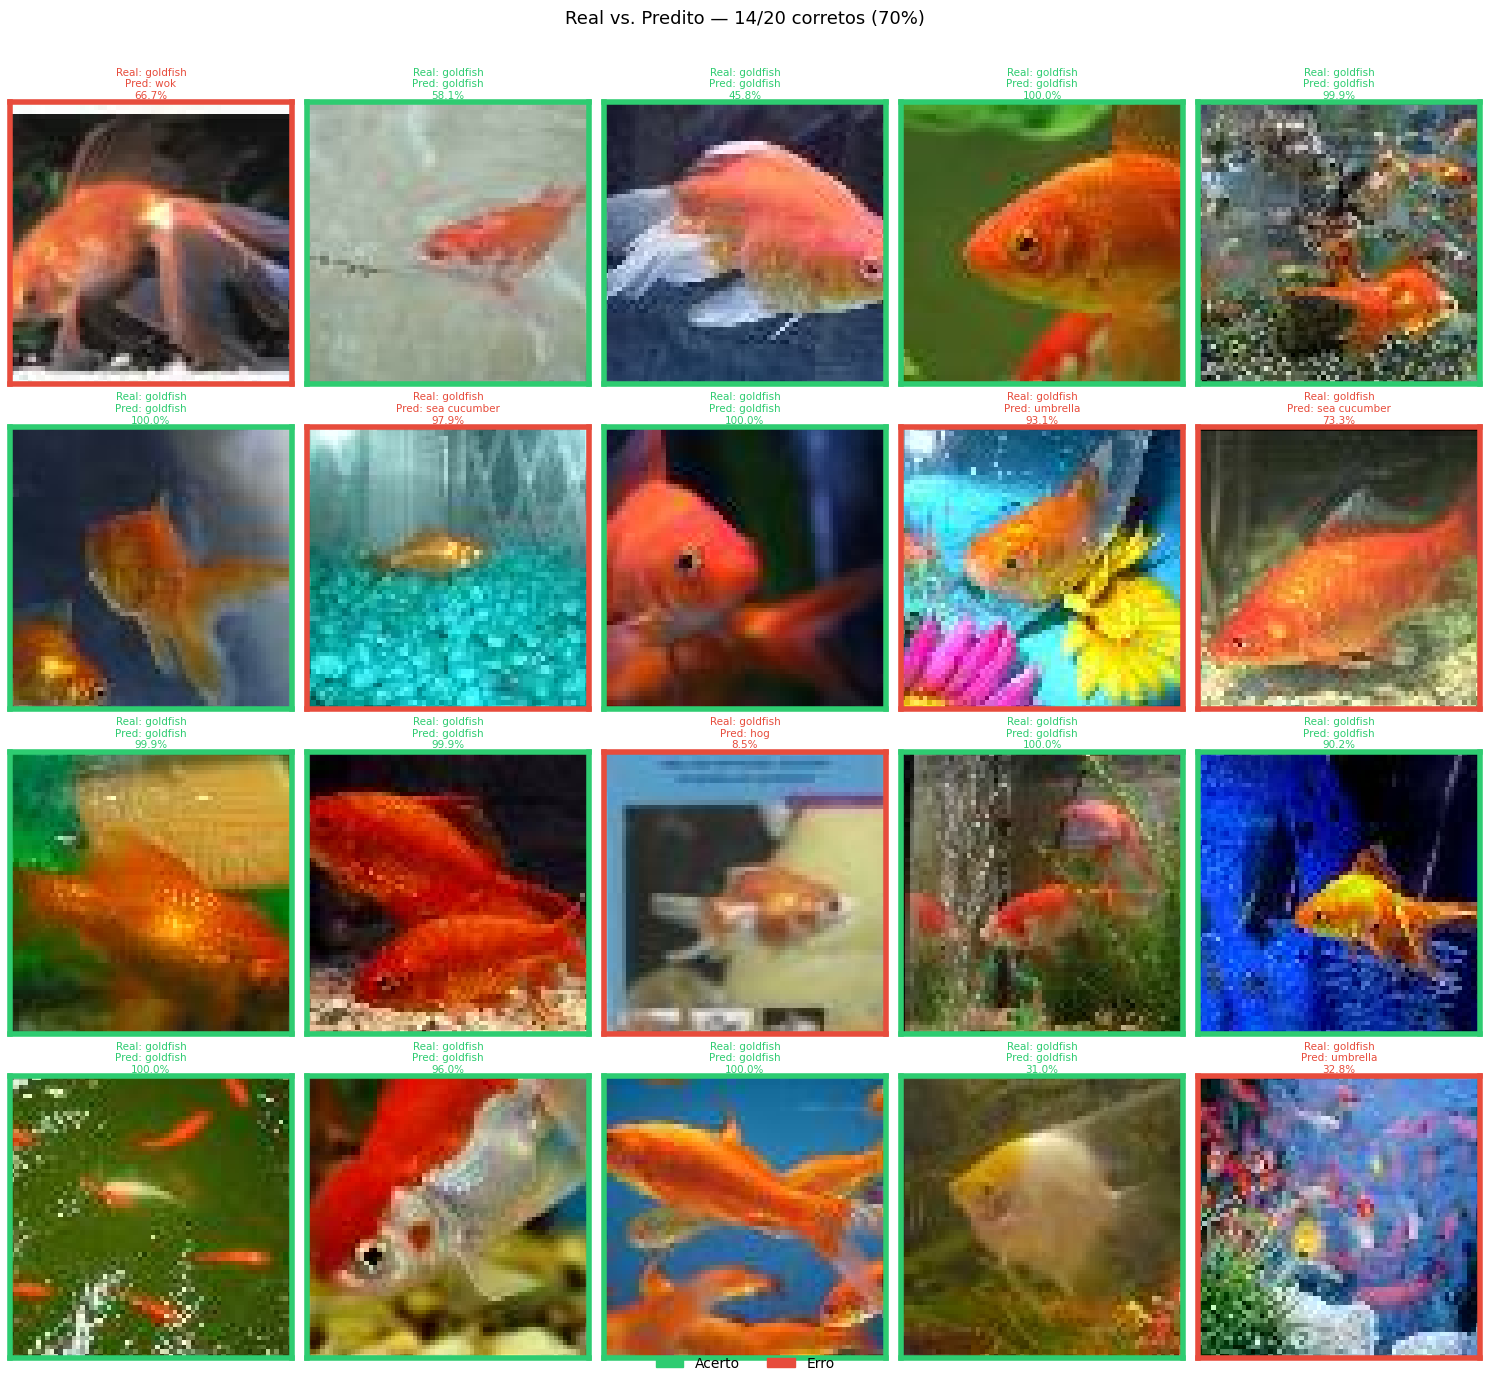

Salvo em real_vs_predito.png


In [16]:
# ── Real vs. Predito — Grade de Imagens (verde = acerto, vermelho = erro) ────
import math

N_AMOSTRAS  = 20   # número de imagens a exibir
COLS        = 5
ROWS        = math.ceil(N_AMOSTRAS / COLS)

# Coleta um batch da validação (sem augmentation)
sample_images, sample_labels_tuple = next(iter(val_ds_dual))
sample_images  = sample_images[:N_AMOSTRAS]
sample_labels  = sample_labels_tuple[0][:N_AMOSTRAS]   # one-hot

true_indices = tf.argmax(sample_labels, axis=1).numpy()
preds_main   = best_model(sample_images, training=False)[0].numpy()
pred_indices = np.argmax(preds_main, axis=1)
confidences  = np.max(preds_main, axis=1)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 3.4))
axes = axes.flat

for i in range(N_AMOSTRAS):
    ax = axes[i]
    img = sample_images[i].numpy()

    true_name = idx_to_readable.get(true_indices[i], str(true_indices[i]))
    pred_name = idx_to_readable.get(pred_indices[i], str(pred_indices[i]))
    correct   = true_indices[i] == pred_indices[i]
    cor_borda = '#2ecc71' if correct else '#e74c3c'   # verde / vermelho

    # Imagem com borda colorida
    ax.imshow(img)
    for spine in ax.spines.values():
        spine.set_edgecolor(cor_borda)
        spine.set_linewidth(4)

    ax.set_title(
        f"Real: {true_name}\nPred: {pred_name}\n{confidences[i]*100:.1f}%",
        fontsize=7.5,
        color=cor_borda,
        pad=3
    )
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Oculta eixos extras
for j in range(N_AMOSTRAS, ROWS * COLS):
    axes[j].axis('off')

# Legenda
verde_patch  = mpatches.Patch(color='#2ecc71', label='Acerto')
vermelho_patch = mpatches.Patch(color='#e74c3c', label='Erro')
fig.legend(handles=[verde_patch, vermelho_patch],
           loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, 0.0), frameon=False)

n_correct = sum(true_indices[i] == pred_indices[i] for i in range(N_AMOSTRAS))
fig.suptitle(
    f'Real vs. Predito — {n_correct}/{N_AMOSTRAS} corretos ({n_correct/N_AMOSTRAS*100:.0f}%)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('real_vs_predito.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em real_vs_predito.png')


In [17]:
import tensorflow as tf
# Definição da métrica Top-5 (ajuste se necessário para one-hot)
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)


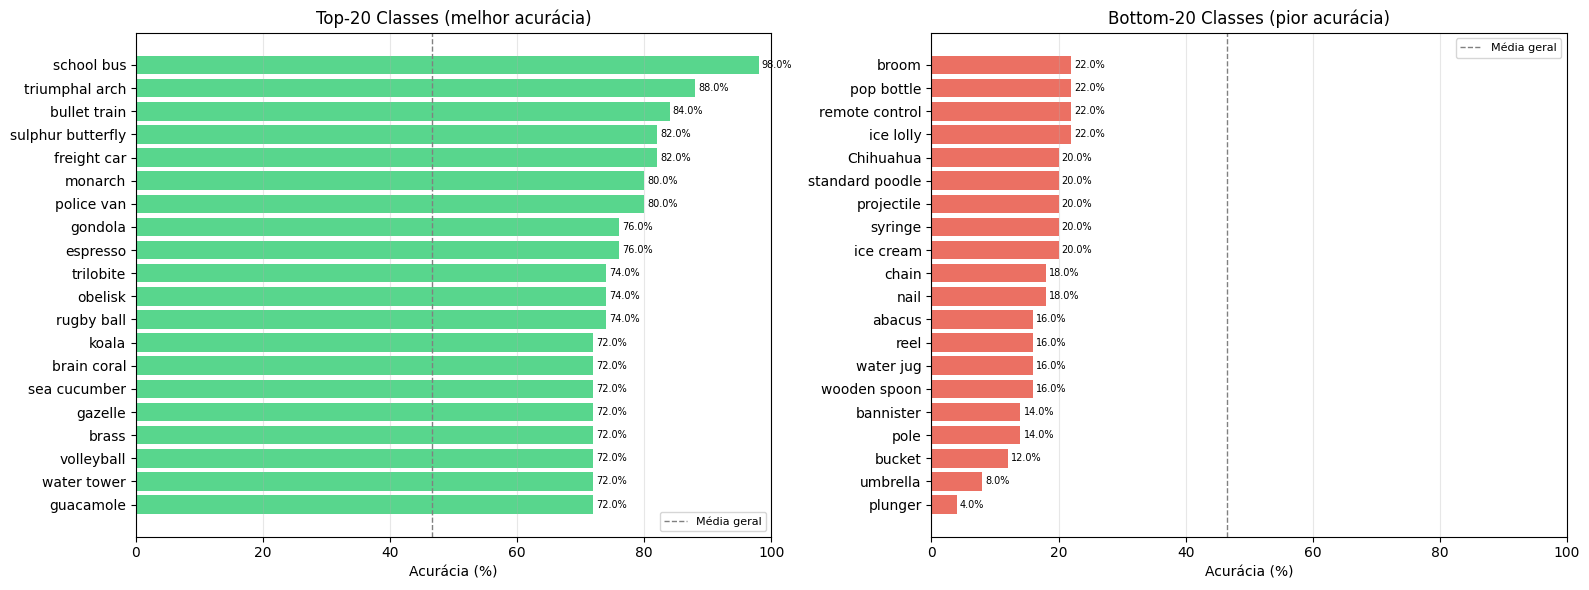

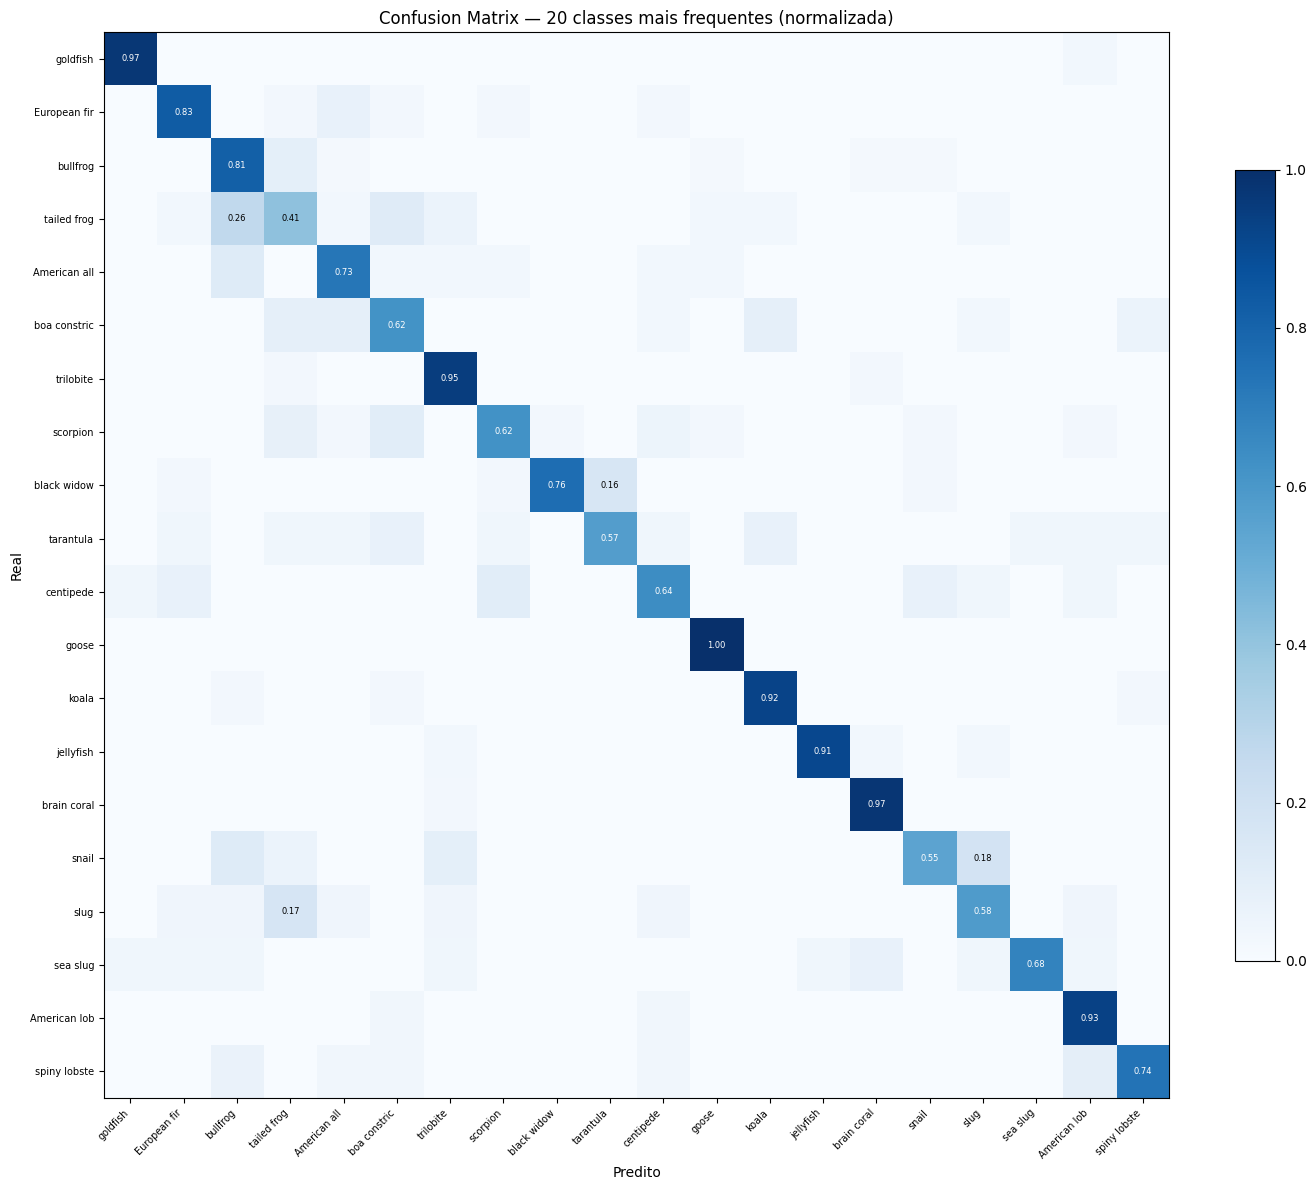


  Top-1 Accuracy  : 46.58%
  Top-5 Accuracy  : 0.00%
  Média per-class : 46.58%
  Melhor classe   : school bus (98.0%)
  Pior classe     : plunger (4.0%)


In [18]:
# ── Métricas Complementares ──────────────────────────────────────────────────
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Coleta predições sobre todo o val set
all_true, all_pred = [], []
for images, (labels, _) in val_ds_dual:
    labels_idx = tf.argmax(labels, axis=1).numpy()
    preds      = best_model(images, training=False)[0].numpy()
    pred_idx   = np.argmax(preds, axis=1)
    all_true.extend(labels_idx)
    all_pred.extend(pred_idx)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# ── 1. Per-class accuracy: top-20 e bottom-20 ────────────────────────────────
per_class_acc = {}
for cls in range(NUM_CLASSES):
    mask = all_true == cls
    if mask.sum() > 0:
        per_class_acc[cls] = (all_pred[mask] == all_true[mask]).mean()

sorted_acc  = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
top20_cls   = sorted_acc[:20]
bot20_cls   = sorted_acc[-20:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in [
    (axes[0], top20_cls,  'Top-20 Classes (melhor acurácia)', '#2ecc71'),
    (axes[1], bot20_cls,  'Bottom-20 Classes (pior acurácia)', '#e74c3c'),
]:
    labels_cls = [idx_to_readable.get(c, str(c)) for c, _ in data]
    values     = [v * 100 for _, v in data]
    bars = ax.barh(labels_cls[::-1], values[::-1], color=color, alpha=0.8)
    ax.set_xlabel('Acurácia (%)')
    ax.set_title(title)
    ax.axvline(np.mean(list(per_class_acc.values())) * 100,
               color='gray', linestyle='--', linewidth=1, label='Média geral')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 100)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, values[::-1]):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Confusion matrix — 20 classes mais frequentes ─────────────────────────
from sklearn.metrics import confusion_matrix
import itertools

top20_by_count = [cls for cls, _ in
                  sorted(((c, (all_true == c).sum()) for c in range(NUM_CLASSES)),
                         key=lambda x: -x[1])[:20]]

mask_top20 = np.isin(all_true, top20_by_count)
cm = confusion_matrix(all_true[mask_top20], all_pred[mask_top20], labels=top20_by_count)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
tick_labels = [idx_to_readable.get(c, str(c))[:12] for c in top20_by_count]
ax.set_xticks(range(20)); ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(20)); ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_title('Confusion Matrix — 20 classes mais frequentes (normalizada)', fontsize=12)
ax.set_ylabel('Real'); ax.set_xlabel('Predito')
for i, j in itertools.product(range(20), range(20)):
    val = cm_norm[i, j]
    if val > 0.15:
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if val > 0.5 else 'black', fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Resumo numérico ────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Top-1 Accuracy  : {(all_true == all_pred).mean()*100:.2f}%")
print(f"  Top-5 Accuracy  : {top5_metric.result().numpy()*100:.2f}%")
print(f"  Média per-class : {np.mean(list(per_class_acc.values()))*100:.2f}%")
print(f"  Melhor classe   : {idx_to_readable.get(sorted_acc[0][0])} ({sorted_acc[0][1]*100:.1f}%)")
print(f"  Pior classe     : {idx_to_readable.get(sorted_acc[-1][0])} ({sorted_acc[-1][1]*100:.1f}%)")
print(f"{'='*50}")


In [19]:
# ── Salvar resultado do experimento ──────────────────────────────────────────
import csv, os, datetime

EXPERIMENTO["resultado_top1"] = round(float(results[3]) * 100, 2)
EXPERIMENTO["resultado_top5"] = round(top5_metric.result().numpy() * 100, 2)
EXPERIMENTO["epocas"]         = len(history.history["loss"])

log_path = "experimentos_log.csv"
fieldnames = ["id", "hipotese", "mudancas", "resultado_top1", "resultado_top5", "epocas", "timestamp"]

row = {**EXPERIMENTO,
       "mudancas"  : " | ".join(EXPERIMENTO["mudancas"]),
       "timestamp" : datetime.datetime.now().isoformat()}

file_exists = os.path.isfile(log_path)
with open(log_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()
    writer.writerow(row)

print(f"✓ Experimento {EXPERIMENTO['id']} salvo em {log_path}")
print(f"  Top-1: {EXPERIMENTO['resultado_top1']}%  |  Top-5: {EXPERIMENTO['resultado_top5']}%  |  Épocas: {EXPERIMENTO['epocas']}")


✓ Experimento exp_002 salvo em experimentos_log.csv
  Top-1: 39.29%  |  Top-5: 0.0%  |  Épocas: 94


## Top-5 Accuracy

No ImageNet, a métrica padrão é Top-5. Calculamos manualmente sobre o conjunto de validação.

In [20]:
top5_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

for images, (labels, _) in val_ds_dual:
    # labels estão em one-hot; convertemos para índices
    labels_idx = tf.argmax(labels, axis=1)
    main_preds = best_model(images, training=False)[0]
    top5_metric.update_state(labels_idx, main_preds)

print(f'Top-5 Accuracy (val): {top5_metric.result().numpy()*100:.2f}%')

Top-5 Accuracy (val): 71.79%


## Predição em Imagens Externas

Tiny ImageNet usa um subconjunto das 200 classes do WordNet. As classes são identificadas por códigos `nXXXXXXXX`. O dicionário abaixo mapeia código → nome legível para as classes mais comuns.

In [21]:
def predict_url(url, top_k=3):
    """Baixa uma imagem, redimensiona e retorna as top-k predições."""
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img_resized = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        arr = np.array(img_resized, dtype=np.float32) / 255.0
        arr = np.expand_dims(arr, axis=0)

        # best_model retorna [main_out, aux_out]
        main_preds = best_model.predict(arr, verbose=0)[0][0]
        top_indices = np.argsort(main_preds)[::-1][:top_k]

        print(f'URL: {url.split("/")[-1]}')
        for rank, idx in enumerate(top_indices, 1):
            print(f'  Top-{rank}: {idx_to_readable[idx]} ({main_preds[idx]*100:.1f}%)')

        # Exibe imagem com predição
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.imshow(img_resized)
        ax.set_title(f'Pred: {idx_to_readable[top_indices[0]]}\n({main_preds[top_indices[0]]*100:.1f}%)',
                     fontsize=10)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Erro: {e}')

# Exemplos com objetos presentes no Tiny ImageNet
predict_url('https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/640px-Cat_November_2010-1a.jpg')
predict_url('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/640px-Camponotus_flavomarginatus_ant.jpg')

Erro: cannot identify image file <_io.BytesIO object at 0x7d5167f0ddf0>
Erro: cannot identify image file <_io.BytesIO object at 0x7d51676bb1f0>


## Resumo dos Resultados

| Métrica | Valor |
|---|---|
| Top-1 Accuracy (val) | *(preencher após treino)* |
| Top-5 Accuracy (val) | *(preencher após treino)* |
| Épocas até convergência | *(preencher)* |
| Parâmetros totais | *(ver model.summary())* |

### Referência de acurácia no Tiny ImageNet
- Baseline MLP simples: ~5%
- ResNet-18 padrão: ~65% Top-1
- GoogLeNet adaptado: ~55–60% Top-1 esperado